# Parametric surfaces

We can define a surface in 3D ($(x, y, z)$) using 2D coordinates ($(u,v)$). For example, 
consider:

$$
x = v\cos(u)
$$
$$
y = v\sin(u)
$$
and
$$
z = v^2
$$

for $0 \leq v \leq 2$ and $0 \leq u \leq 2\pi$. This surface is parabolic in the 
$z$ direction and defines a circle of radius $v$ in the $xy$ plane.

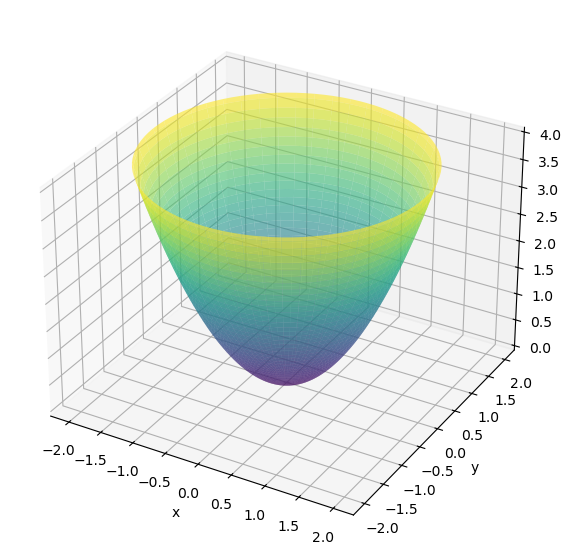

In [4]:
import numpy as np 
import matplotlib.pyplot as plt 

# Create u and v axis
N = 100
u_min = 0
u_max = 2*np.pi
v_min = 0
v_max = 2
u = np.linspace(u_min, u_max, N)
v = np.linspace(v_min, v_max, N)
U, V = np.meshgrid(u, v)

# Create x, y, and z axis
X = V*np.cos(U)
Y = V*np.sin(U)
Z = V**2

# Create figure
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.6, edgecolor="none")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

Anywhere on the surface can be represented by the pair of $(u,v)$ values.

In the figure below, we show the $(u,v)$ coordinates on the surface. Lines 
at constant $u$ are blue (vertical axis here) and lines of constant $v$ are 
red (horizontal axis here).

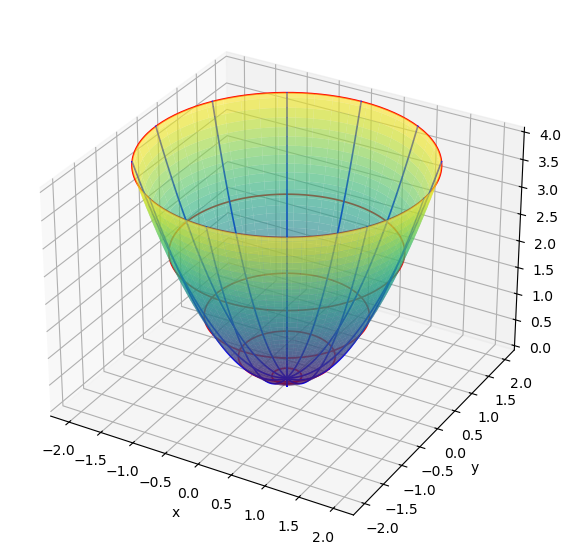

In [ ]:
# Create figure
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.6, edgecolor="none")

# Constant v lines
v_lines = np.linspace(0.2, v_max, 5)
for v0 in v_lines:
    u_curve = np.linspace(u_min, u_max, 200)
    x_u = v0 * np.cos(u_curve)
    y_u = v0 * np.sin(u_curve)
    z_u = v0**2 * np.ones_like(u_curve)
    ax.plot(x_u, y_u, z_u, color="red", linewidth=1.2)

# Constant u lines
u_lines = np.linspace(u_min, u_max, 12, endpoint=False)
for u0 in u_lines:
    v_curve = np.linspace(v_min, v_max, 200)
    x_v = v_curve * np.cos(u0)
    y_v = v_curve * np.sin(u0)
    z_v = v_curve**2
    ax.plot(x_v, y_v, z_v, color="blue", linewidth=1.2)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

## Finding d $\vec{A}$

Consider a planar surface in the $xy$ plane defined by:

$$
x = 2u + v
$$
$$
y = u-v
$$
and
$$
z = 2v
$$

We show below what the surface looks like along with lines of constant $v$ (red) and constant $u$ (blue).

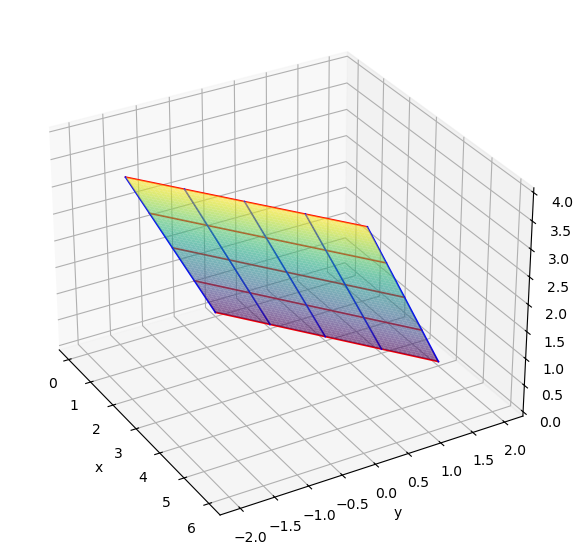

In [17]:
import numpy as np 
import matplotlib.pyplot as plt 

# Create u and v axis
N = 100
u_min = 0.0
u_max = 2.0
v_min = 0.0
v_max = 2.0
u = np.linspace(u_min, u_max, N)
v = np.linspace(v_min, v_max, N)
U, V = np.meshgrid(u, v)

# Create x, y, and z axis
def X(U, V):
    return 2*U+V

def Y(U, V):
    return U-V

def Z(U, V):
    return 2*V

# Create figure
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X(U,V), Y(U,V), Z(U,V), cmap="viridis", alpha=0.6, edgecolor="none")

# Constant v lines
v_lines = np.linspace(v_min, v_max, 5)
for v0 in v_lines:
    u_curve = np.linspace(u_min, u_max, 200)
    x_u = X(u_curve, v0)
    y_u = Y(u_curve, v0)
    z_u = Z(u_curve, v0)
    ax.plot(x_u, y_u, z_u, color="red", linewidth=1.2)

# Constant u lines
u_lines = np.linspace(u_min, u_max, 5)
for u0 in u_lines:
    v_curve = np.linspace(v_min, v_max, 200)
    x_v = X(u0, v_curve)
    y_v = Y(u0, v_curve)
    z_v = Z(u0, v_curve)
    ax.plot(x_v, y_v, z_v, color="blue", linewidth=1.2)

ax.azim=-30
ax.elev=30 

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()


A surface element has magnitude of a square on the $uv$ plane in the limit when those squares are small and points perpendicular to the surface. This is true even for non-planar surfaces. The definition is:

$$
d\vec{A} = \left(\frac{\partial \vec{r}}{\partial u}\times\frac{\partial \vec{r}}{\partial v}\right) dudv
$$

with

$$
\vec{r} = x\hat{i} + y\hat{j} + z\hat{z}
$$

In our example from above, we get:

$$
\vec{r} = (2u+v)\hat{i} + (u-v)\hat{j} + 2v\hat{k}
$$

Hence, 

$$
\vec{a} = \frac{\partial \vec{r}}{\partial u} = 2\hat{i} + \hat{j}
$$

and 

$$
\vec{b} = \frac{\partial \vec{r}}{\partial v} = \hat{i} - \hat{j} + 2\hat{k}
$$

Taking the cross-product, we can calculate the area element vector:

$$
\begin{align}
d\vec{A} &=& \left(\frac{\partial \vec{r}}{\partial u}\times\frac{\partial \vec{r}}{\partial v}\right) dudv \\
&=& \begin{vmatrix}
\hat{i} & \hat{j} & \hat{k} \\
2 & 1 & 0 \\
1 & -1 & 2 
\end{vmatrix}
dudv \\
&=& (2\hat{i} - 4\hat{j} - 3\hat{k})dudv \\
&=& \vec{c}dudv \\
\end{align}
$$

Below, we plot $\vec{a}$, $\vec{b}$, and $\vec{c}$.

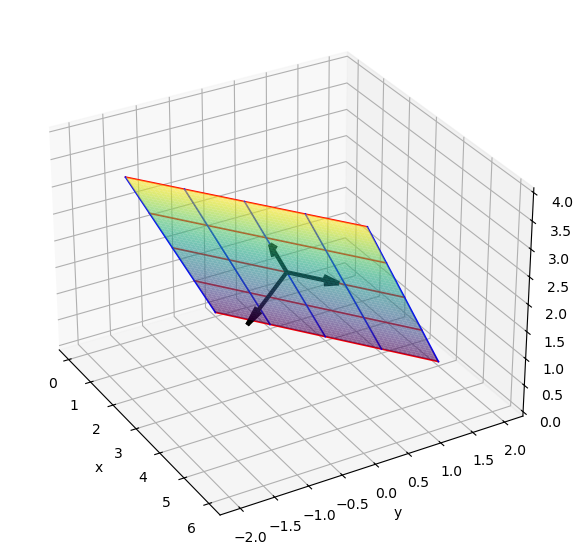

In [21]:
# Create figure
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X(U,V), Y(U,V), Z(U,V), cmap="viridis", alpha=0.6, edgecolor="none")

# Constant v lines
v_lines = np.linspace(v_min, v_max, 5)
for v0 in v_lines:
    u_curve = np.linspace(u_min, u_max, 200)
    x_u = X(u_curve, v0)
    y_u = Y(u_curve, v0)
    z_u = Z(u_curve, v0)
    ax.plot(x_u, y_u, z_u, color="red", linewidth=1.2)

# Constant u lines
u_lines = np.linspace(u_min, u_max, 5)
for u0 in u_lines:
    v_curve = np.linspace(v_min, v_max, 200)
    x_v = X(u0, v_curve)
    y_v = Y(u0, v_curve)
    z_v = Z(u0, v_curve)
    ax.plot(x_v, y_v, z_v, color="blue", linewidth=1.2)

u0 = u_lines[2]
v0 = v_lines[2]
# a vector
ax.quiver(X(u0, v0), Y(u0, v0), Z(u0, v0), 2, 1, 0, linewidth=3, color='k', normalize=True)
# b vector
ax.quiver(X(u0, v0), Y(u0, v0), Z(u0, v0), 1, -1, 2, linewidth=3, color='k', normalize=True)
# dA vector 
ax.quiver(X(u0, v0), Y(u0, v0), Z(u0, v0), 2, -4, -3, linewidth=3, color='k', normalize=True)

ax.azim=-30
ax.elev=30 

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

